In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib as plt
import os

# 1. Load dataset

In [2]:
#Comment out nếu chạy offline / dùng Kaggle
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Thay đổi đường dẫn cho phù hợp với môi trường chạy của bạn
DATA_DIR = '/content/drive/MyDrive/Datathon-2026/'

In [4]:
customers = pd.read_csv(DATA_DIR + 'customers.csv')
geography = pd.read_csv(DATA_DIR + 'geography.csv')
inventory = pd.read_csv(DATA_DIR + 'inventory.csv')
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
orders = pd.read_csv(DATA_DIR + 'orders.csv')
payments = pd.read_csv(DATA_DIR + 'payments.csv')
products = pd.read_csv(DATA_DIR + 'products.csv')
promotions = pd.read_csv(DATA_DIR + 'promotions.csv')
returns = pd.read_csv(DATA_DIR + 'returns.csv')
reviews = pd.read_csv(DATA_DIR + 'reviews.csv')
shipments = pd.read_csv(DATA_DIR + 'shipments.csv')
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')
sales = pd.read_csv(DATA_DIR + 'sales.csv')
sample_submission = pd.read_csv(DATA_DIR + 'sample_submission.csv')

# 2. MCQs

Câu 1: Trong số các khách hàng có nhiều hơn một đơn hàng, trung vị số ngày giữa hai lần mua liên tiếp (inter-order gap) xấp xỉ là bao nhiêu? (Tính từ orders.csv)

In [5]:
orders.head()
orders['order_status'].value_counts()

,count
order_status,
delivered,516716
cancelled,59462
returned,36142
shipped,13773
paid,13577
created,7275


In [6]:
shipments.head()

,order_id,ship_date,delivery_date,shipping_fee
0,1,2012-07-07,2012-07-11,1.37
1,2,2012-07-06,2012-07-10,2.60
2,3,2012-07-04,2012-07-07,2.38
3,4,2012-07-05,2012-07-11,2.49
4,6,2012-07-09,2012-07-16,25.79


In [7]:
returns.head()
returns['return_reason'].value_counts()

,count
return_reason,
wrong_size,13967
defective,8020
not_as_described,7035
changed_mind,6931
late_delivery,3986


In [8]:
def calculate_median_interorder_gap(df):
    # 1. Ensure order_date is datetime
    df['order_date'] = pd.to_datetime(df['order_date'])

    # 2. Sort by customer and date to calculate gaps correctly
    df_sorted = df.sort_values(by=['customer_id', 'order_date'])

    # 3. Filter for customers with > 1 order
    customer_counts = df_sorted['customer_id'].value_counts()
    repeat_customers = customer_counts[customer_counts > 1].index
    df_repeat = df_sorted[df_sorted['customer_id'].isin(repeat_customers)].copy()

    # 4. Calculate the difference between consecutive orders for each customer
    df_repeat['order_gap'] = df_repeat.groupby('customer_id')['order_date'].diff().dt.days

    # 5. Drop NaNs (the first order of each customer has no gap)
    inter_order_gaps = df_repeat['order_gap'].dropna()

    # 6. Calculate median
    median_gap = inter_order_gaps.median()

    return median_gap

# Calculate and print the result
result = calculate_median_interorder_gap(orders)
print(f"Trung vị số ngày giữa hai lần mua liên tiếp là: {result} ngày")

Trung vị số ngày giữa hai lần mua liên tiếp là: 144.0 ngày


Câu 2: Phân khúc sản phẩm (segment) nào trong products.csv có tỷ suất lợi nhuận gộp trung bình cao nhất, với công thức (price − cogs)/price?

In [9]:
print("\n=== Q2: Segment with highest avg gross margin ===")
products["gross_margin"] = (products["price"] - products["cogs"]) / products["price"]
result = products.groupby("segment")["gross_margin"].mean().sort_values(ascending=False)
print(result)


=== Q2: Segment with highest avg gross margin ===
segment
Standard       0.313442
Premium        0.285377
All-weather    0.284176
Activewear     0.265600
Performance    0.263650
Balanced       0.258038
Trendy         0.240758
Everyday       0.236343
Name: gross_margin, dtype: float64


Câu 3: Trong các bản ghi trả hàng liên kết với sản phẩm thuộc danh mục Streetwear (join returns với products theo product_id), lý do trả hàng nào xuất hiện nhiều nhất?

In [10]:
print("\n=== Q3: Top return reason for Streetwear ===")
merged = returns.merge(products[["product_id","category"]], on="product_id")
streetwear = merged[merged["category"] == "Streetwear"]
print(streetwear["return_reason"].value_counts())


=== Q3: Top return reason for Streetwear ===
return_reason
wrong_size          7626
defective           4330
not_as_described    3854
changed_mind        3830
late_delivery       2159
Name: count, dtype: int64


Câu 4: Trong web_traffic.csv, nguồn truy cập (traffic_source) nào có tỷ lệ thoát trung bình (bounce_rate) thấp nhất trên tất cả các ngày mà  nguồn đó xuất hiện?

In [11]:
result = web_traffic.groupby("traffic_source")["bounce_rate"].mean().sort_values()
print(result)


traffic_source
email_campaign    0.004458
social_media      0.004476
paid_search       0.004478
referral          0.004499
organic_search    0.004504
direct            0.004511
Name: bounce_rate, dtype: float64


Câu 5: Tỷ lệ phần trăm các dòng trong order_items.csv có áp dụng khuyến mãi (tức là promo_id không null) xấp xỉ là bao nhiêu?

In [12]:
pct = order_items["promo_id"].notna().mean() * 100
print(f"Promo applied: {pct:.1f}%")


Promo applied: 38.7%


Câu 6: Trong customers.csv, xét các khách hàng có age_group khác null, nhóm tuổi nào có số đơn hàng trung bình trên mỗi khách hàng cao nhất? (tổng số đơn / số khách hàng trong nhóm)

In [13]:
cust_notnull = customers[customers["age_group"].notna()]
order_counts = orders.groupby("customer_id").size().reset_index(name="n_orders")
merged = cust_notnull.merge(order_counts, on="customer_id", how="left").fillna(0)
result = merged.groupby("age_group")["n_orders"].mean().sort_values(ascending=False)
print(result)


age_group
55+      5.406851
45-54    5.357241
35-44    5.337343
25-34    5.245226
18-24    5.226656
Name: n_orders, dtype: float64


Câu 7: Vùng (region) nào trong geography.csv tạo ra tổng doanh thu cao nhất trong sales_train.csv?

In [14]:
order_rev = order_items.merge(orders[["order_id","zip"]], on="order_id")
order_rev = order_rev.merge(geography[["zip","region"]], on="zip")
order_rev["revenue_line"] = order_rev["quantity"] * order_rev["unit_price"]
result = order_rev.groupby("region")["revenue_line"].sum().sort_values(ascending=False)
print(result)


region
East       7.637533e+09
Central    4.941908e+09
West       3.851035e+09
Name: revenue_line, dtype: float64


Câu 8: Trong các đơn hàng có order_status = ’cancelled’ trong orders.csv, phương thức thanh toán nào được sử dụng nhiều nhất?

In [15]:
print("\n=== Q8: Payment method most used in cancelled orders ===")
cancelled = orders[orders["order_status"] == "cancelled"]
print(cancelled["payment_method"].value_counts())



=== Q8: Payment method most used in cancelled orders ===
payment_method
credit_card      28452
cod              15468
paypal            7817
apple_pay         5190
bank_transfer     2535
Name: count, dtype: int64


Câu 9: Trong bốn kích thước sản phẩm (S, M, L, XL), kích thước nào có tỷ lệ trả hàng cao nhất, được định nghĩa là số bản ghi trong returns chia cho số dòng trong order_items (join với products theo product_id)?

In [16]:
print("\n=== Q9: Size with highest return rate ===")
oi_prod = order_items.merge(products[["product_id","size"]], on="product_id")
ret_prod = returns.merge(products[["product_id","size"]], on="product_id")
order_cnt = oi_prod.groupby("size").size().rename("order_lines")
return_cnt = ret_prod.groupby("size").size().rename("return_lines")
rate = (return_cnt / order_cnt).sort_values(ascending=False)
print(rate)



=== Q9: Size with highest return rate ===
size
S     0.056515
L     0.056250
M     0.055660
XL    0.055200
dtype: float64


Câu 10: Trong payments.csv, kế hoạch trả góp nào có giá trị thanh toán trung bình trên mỗi đơn hàng cao nhất?

In [17]:
print("\n=== Q10: Installment plan with highest avg payment_value ===")
result = payments.groupby("installments")["payment_value"].mean().sort_values(ascending=False)
print(result)


=== Q10: Installment plan with highest avg payment_value ===
installments
6     24446.654403
3     24399.635486
12    24245.772694
1     24113.274166
2       708.473729
Name: payment_value, dtype: float64


In [18]:
products.head()

,product_id,product_name,category,segment,size,color,price,cogs,gross_margin
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875,0.1225
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254,0.4336
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278,0.2871
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954,0.4558
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406,0.1080


In [19]:
geography.head()

,zip,city,region,district
0,15201,Hai Phong,East,District #13
1,15202,Phu Ly,East,District #13
2,15203,Viet Tri,East,District #13
3,15204,Bac Giang,East,District #13
4,15205,Bac Giang,East,District #13


In [20]:
reviews.head()
reviews['review_title'].unique()

array(['Highly recommend', 'Very satisfied', 'Great quality',
       'Good overall', 'Solid choice', 'Works well', 'Excellent product!',
       'Average product', 'Happy with purchase', 'Below expectations',
       'Decent, nothing special', 'Would not recommend',
       'Would not reorder', 'Very disappointed', 'Poor quality',
       'Mixed feelings', 'Not as described', 'Some issues'], dtype=object)

In [21]:
returns.head()
returns['return_reason'].unique()

array(['late_delivery', 'wrong_size', 'defective', 'changed_mind',
       'not_as_described'], dtype=object)

# 3. EDA

AOV theo thời gian

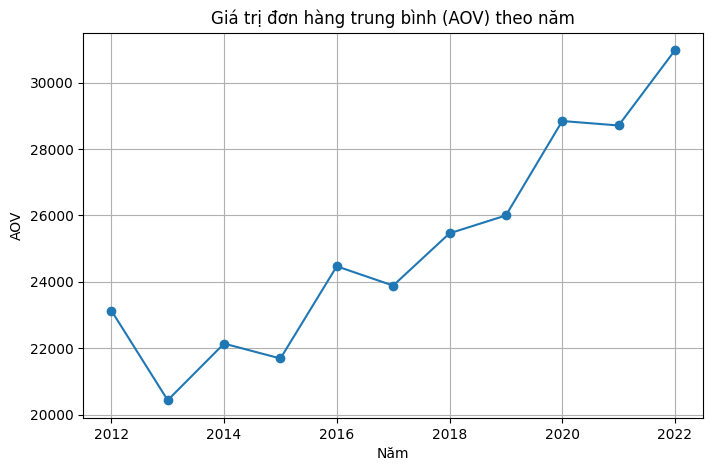

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. JOIN DATA =====
payments_orders = payments.merge(
    orders[['order_id', 'order_date']],
    on='order_id',
    how='left'
)

# Convert sang datetime
payments_orders['order_date'] = pd.to_datetime(payments_orders['order_date'])

# Extract year
payments_orders['year'] = payments_orders['order_date'].dt.year


# ===== 2. CALCULATE AOV BY YEAR =====
aov_yearly = (
    payments_orders
    .groupby('year')
    .agg(
        total_payment_value=('payment_value', 'sum'),
        total_orders=('order_id', 'nunique')
    )
    .reset_index()
)

aov_yearly['AOV'] = (
    aov_yearly['total_payment_value'] /
    aov_yearly['total_orders']
)


# ===== 3. PLOT LINE CHART =====
plt.figure(figsize=(8, 5))
plt.plot(aov_yearly['year'], aov_yearly['AOV'], marker='o')

plt.xlabel('Năm')
plt.ylabel('AOV')
plt.title('Giá trị đơn hàng trung bình (AOV) theo năm')

plt.grid(True)
plt.show()

Sell_through_rate theo thời thời gian

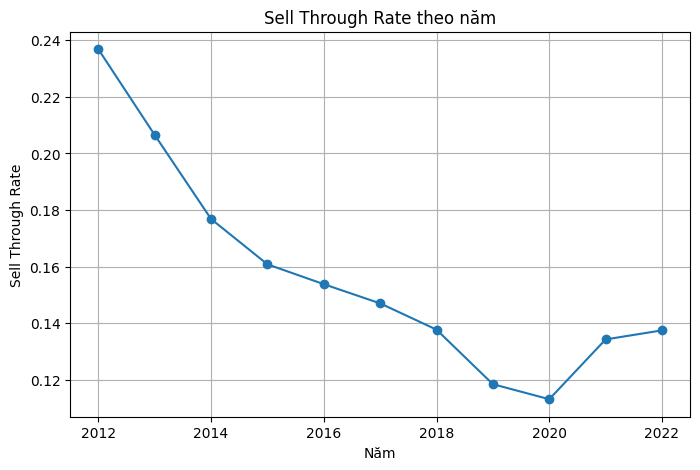

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. PREPARE DATA =====
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'])

# Extract year
inventory['year'] = inventory['snapshot_date'].dt.year

# ===== 2. AGGREGATE =====
sell_through_yearly = (
    inventory
    .groupby('year')
    .agg(
        sell_through_rate=('sell_through_rate', 'mean')  # hoặc weighted nếu cần
    )
    .reset_index()
)

# ===== 3. PLOT =====
plt.figure(figsize=(8, 5))
plt.plot(
    sell_through_yearly['year'],
    sell_through_yearly['sell_through_rate'],
    marker='o'
)

plt.xlabel('Năm')
plt.ylabel('Sell Through Rate')
plt.title('Sell Through Rate theo năm')

plt.grid(True)
plt.show()

Tổng số lượng đơn hàng và AOV theo Order source

/tmp/ipykernel_6174/4229846159.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(summary['order_source'], rotation=15, ha='center')


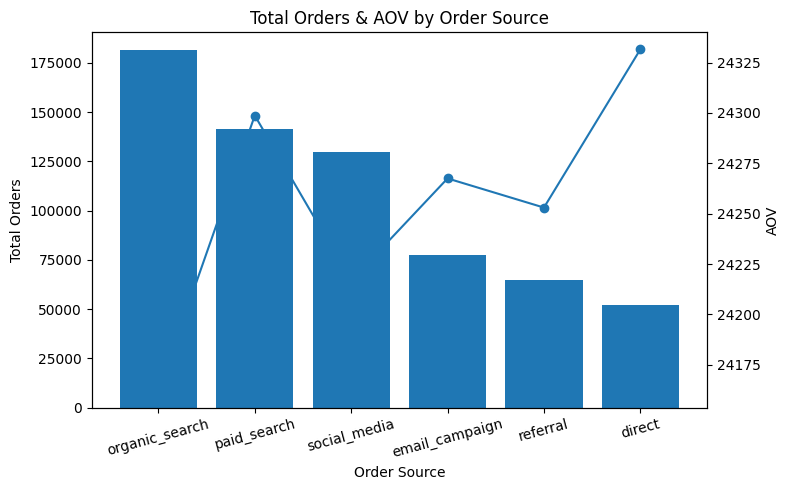

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. PREPARE DATA =====
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Join payments với orders
df = payments.merge(
    orders[['order_id', 'order_date', 'order_source']],
    on='order_id',
    how='left'
)

# (Optional) filter theo thời gian nếu cần
# df = df[df['order_date'] >= '2024-01-01']


# ===== 2. AGGREGATE =====
summary = (
    df
    .groupby('order_source')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_payment=('payment_value', 'sum')
    )
    .reset_index()
)

summary['AOV'] = summary['total_payment'] / summary['total_orders']


# ===== 3. SORT (để chart đẹp hơn) =====
summary = summary.sort_values('total_orders', ascending=False)


# ===== 4. PLOT (BAR + LINE) =====
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar chart: total orders
ax1.bar(summary['order_source'], summary['total_orders'])
ax1.set_ylabel('Total Orders')
ax1.set_xlabel('Order Source')

# Line chart: AOV
ax2 = ax1.twinx()
ax2.plot(summary['order_source'], summary['AOV'], marker='o')
ax2.set_ylabel('AOV')

plt.title('Total Orders & AOV by Order Source')
ax1.set_xticklabels(summary['order_source'], rotation=15, ha='center')
plt.tight_layout()

plt.show()

Tăng trưởng của Số lượng đơn hàng vs Số lượng KH đăng ký mới theo thời gian

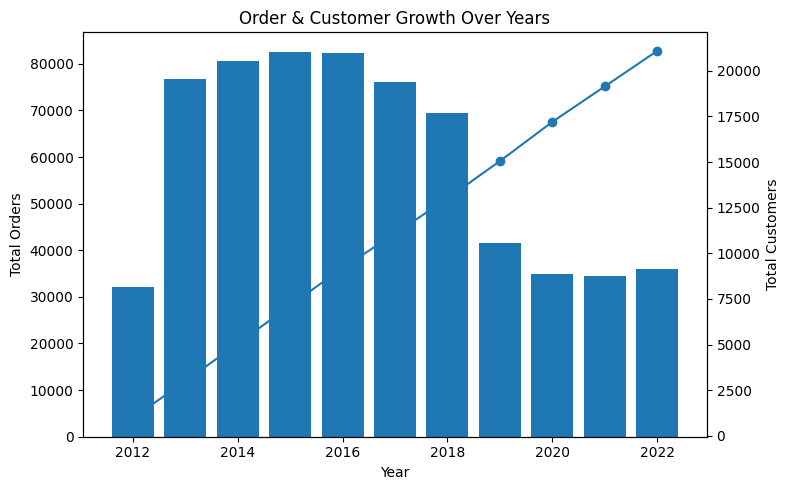

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. PREPARE DATA =====
orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])

# Extract year
orders['year'] = orders['order_date'].dt.year
customers['year'] = customers['signup_date'].dt.year


# ===== 2. AGGREGATE =====
orders_yearly = (
    orders
    .groupby('year')
    .agg(total_orders=('order_id', 'nunique'))
    .reset_index()
)

customers_yearly = (
    customers
    .groupby('year')
    .agg(total_customers=('customer_id', 'nunique'))
    .reset_index()
)


# ===== 3. MERGE =====
growth_df = orders_yearly.merge(
    customers_yearly,
    on='year',
    how='outer'
).sort_values('year')

# Fill missing nếu có
growth_df = growth_df.fillna(0)


# ===== 4. PLOT =====
fig, ax1 = plt.subplots(figsize=(8, 5))

# Bar chart: Orders
ax1.bar(growth_df['year'], growth_df['total_orders'])
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Orders')

# Line chart: Customers
ax2 = ax1.twinx()
ax2.plot(growth_df['year'], growth_df['total_customers'], marker='o')
ax2.set_ylabel('Total Customers')

plt.title('Order & Customer Growth Over Years')

plt.tight_layout()
plt.show()

Tỉ lệ dormant rate (KH đăng ký nhưng không mua) theo thời gian

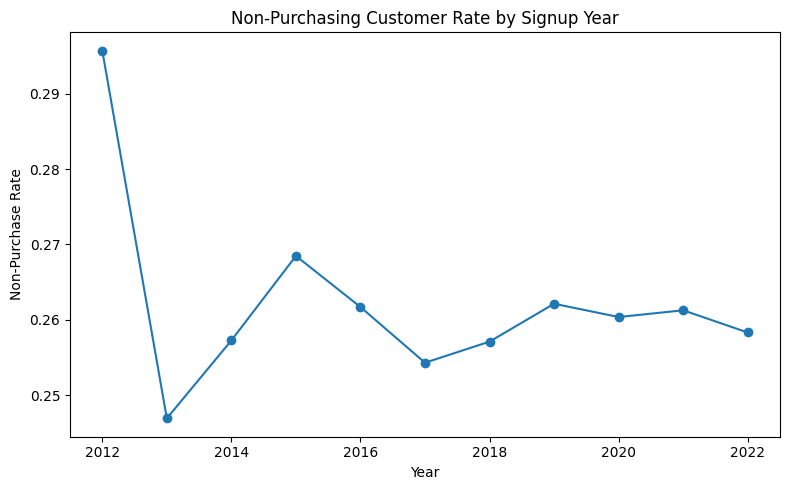

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. PREPARE DATA =====
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

customers['year'] = customers['signup_date'].dt.year

# ===== 2. FLAG CUSTOMER HAS ORDER =====
# Lấy danh sách customer đã từng mua
customers_with_orders = orders['customer_id'].dropna().unique()

customers['has_order'] = customers['customer_id'].isin(customers_with_orders)


# ===== 3. AGGREGATE =====
summary = (
    customers
    .groupby('year')
    .agg(
        total_customers=('customer_id', 'nunique'),
        customers_with_orders=('has_order', 'sum')
    )
    .reset_index()
)

summary['customers_without_orders'] = (
    summary['total_customers'] - summary['customers_with_orders']
)

summary['non_purchase_rate'] = (
    summary['customers_without_orders'] / summary['total_customers']
)


# ===== 4. PLOT =====
plt.figure(figsize=(8, 5))

plt.plot(summary['year'], summary['non_purchase_rate'], marker='o')

plt.title('Non-Purchasing Customer Rate by Signup Year')
plt.xlabel('Year')
plt.ylabel('Non-Purchase Rate')

plt.tight_layout()
plt.show()

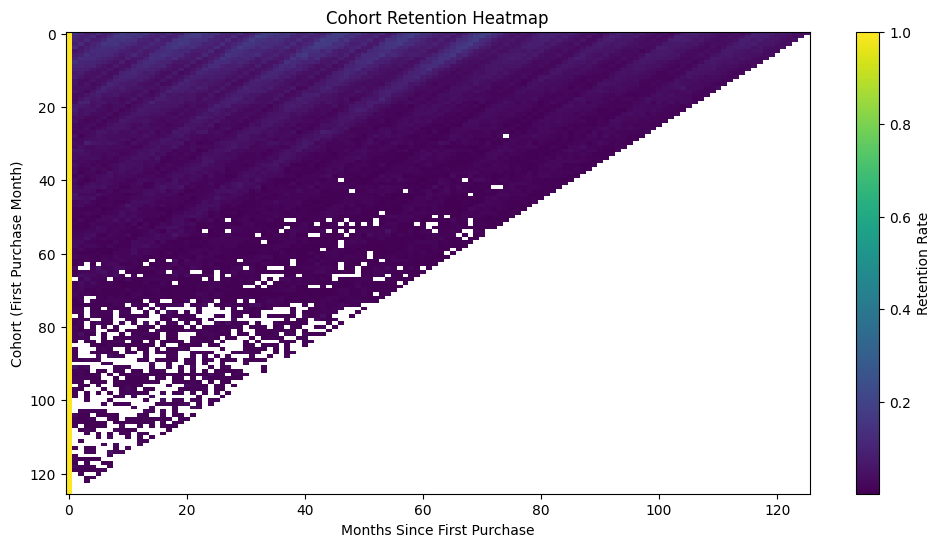

In [27]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_month'] = orders['order_date'].dt.to_period('M')

#Tìm lần mua đầu tiên của mỗi KH
first_purchase = (
    orders
    .groupby('customer_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

#Gắn cohort
df = orders.merge(first_purchase, on='customer_id')
df['cohort_index'] = (
    (df['order_month'].dt.year - df['cohort_month'].dt.year) * 12 +
    (df['order_month'].dt.month - df['cohort_month'].dt.month)
)

cohort_data = (
    df
    .groupby(['cohort_month', 'cohort_index'])['customer_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_id'
)

cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.imshow(retention, aspect='auto')

plt.colorbar(label='Retention Rate')

plt.title('Cohort Retention Heatmap')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')

plt.show()

Tỉ lệ reorder (KH có mua lại) theo từng product segment

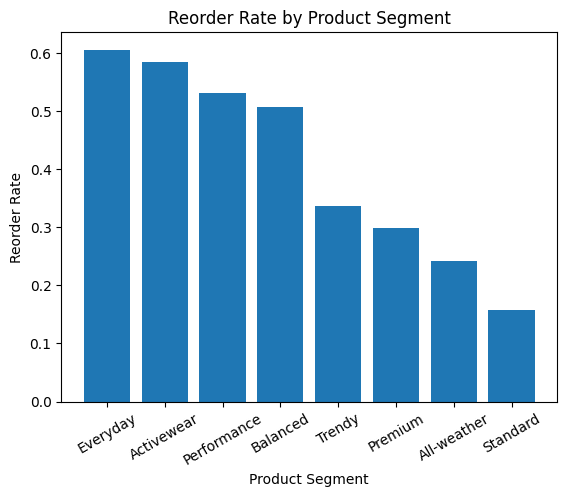

In [28]:
import matplotlib.pyplot as plt

df = (
    orders
    .merge(order_items, on='order_id', how='inner')
    .merge(products, on='product_id', how='inner')
)

customer_segment_orders = (
    df.groupby(['customer_id', 'segment'])['order_id']
      .nunique()
      .reset_index(name='order_count')
)

customer_segment_orders['is_reorder'] = (
    customer_segment_orders['order_count'] >= 2
).astype(int)

segment_stats = (
    customer_segment_orders
    .groupby('segment')
    .agg(
        total_customers=('customer_id', 'nunique'),
        reorder_customers=('is_reorder', 'sum')
    )
    .reset_index()
)

segment_stats['reorder_rate'] = (
    segment_stats['reorder_customers'] / segment_stats['total_customers']
)
#segment_stats['reorder_rate'] = segment_stats['reorder_rate'] * 100
segment_stats = segment_stats.sort_values(by='reorder_rate', ascending=False)

plt.figure()

plt.bar(segment_stats['segment'], segment_stats['reorder_rate'])

plt.xlabel('Product Segment')
plt.ylabel('Reorder Rate')
plt.title('Reorder Rate by Product Segment')

plt.xticks(rotation=30, ha='center')

plt.show()

In [29]:
promotions['applicable_category'].value_counts()

,count
applicable_category,
Streetwear,5
Outdoor,5


In [30]:
promotions.count()

,0
promo_id,50
promo_name,50
promo_type,50
discount_value,50
start_date,50
end_date,50
applicable_category,10
promo_channel,50
stackable_flag,50
min_order_value,50


In [ ]:
#Promotion vs Margin by Segment
#(Figure uploaded in png cause it's way too laggy to save as a file)
df = order_items.merge(products, on='product_id', how='left')

df['gross_revenue'] = df['quantity'] * df['unit_price']
df['net_revenue'] = df['gross_revenue'] - df['discount_amount']
df['cogs_total'] = df['quantity'] * df['cogs']
df['profit'] = df['net_revenue'] - df['cogs_total']
df['margin'] = df['profit'] / df['net_revenue']
df['promotion_rate'] = df['discount_amount'] / df['gross_revenue']

#Flag promotion cho sản phẩm
df['is_promo'] = df['promo_id'].notnull().astype(int)

import plotly.express as px

fig = px.scatter(
    df,
    x='promotion_rate',
    y='margin',
    color='segment',   # từ products
    hover_data=['category'],
    trendline='ols',
    title='Promotion vs Margin by Segment'
)

fig.show()


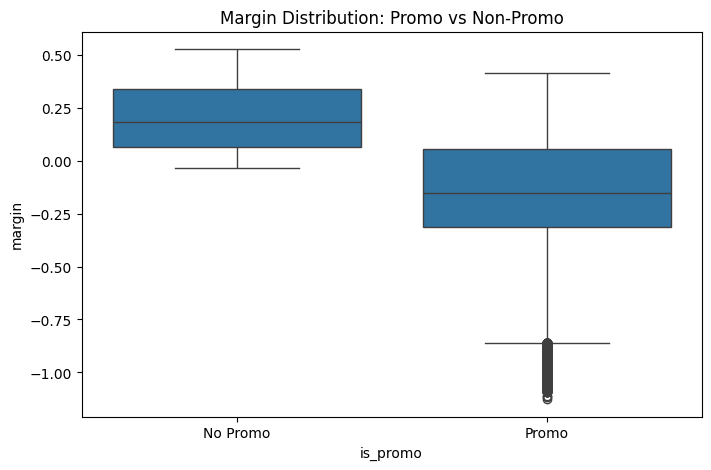

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='is_promo',
    y='margin'
)

plt.xticks([0,1], ['No Promo', 'Promo'])
plt.title('Margin Distribution: Promo vs Non-Promo')
plt.show()

In [ ]:
agg = df.groupby(['category']).agg({
    'margin':'mean',
    'promotion_rate':'mean',
    'net_revenue':'sum'
}).reset_index()

fig = px.scatter(
    agg,
    x='promotion_rate',
    y='margin',
    size='net_revenue',
    color='category',
    title='Promo Efficiency by Category'
)

fig.show()

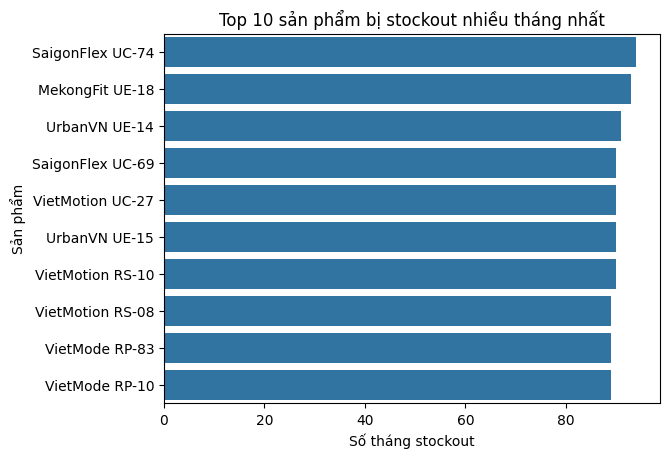

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# chỉ lấy cột cần
inv = inventory[['product_id', 'stockout_flag']]
prod_small = products[['product_id', 'product_name']]

# filter sớm để giảm data
stockout = inv[inv['stockout_flag'] == 1]

# group
stockout_per_product = (
    stockout.groupby('product_id')
    .size()
    .reset_index(name='stockout_months')
)

# merge nhẹ (dimension join)
result = stockout_per_product.merge(prod_small, on='product_id', how='left')

# top 10
top_products = result.sort_values('stockout_months', ascending=False).head(10)

# plot
plt.figure()
sns.barplot(data=top_products, x='stockout_months', y='product_name')
plt.title('Top 10 sản phẩm bị stockout nhiều tháng nhất')
plt.xlabel('Số tháng stockout')
plt.ylabel('Sản phẩm')
plt.show()

In [35]:
# inv = inventory[['snapshot_date', 'product_id', 'stockout_days']].copy()

# inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'])
# inv['year'] = inv['snapshot_date'].dt.to_period('Y')

# yearly_stockout = (
#     inv.groupby('year')['stockout_days']
#     .sum()
#     .reset_index()
# )

# import matplotlib.pyplot as plt
# import seaborn as sns

# yearly_stockout['year'] = yearly_stockout['year'].astype(str)

# plt.figure()
# sns.lineplot(data=yearly_stockout, x='year', y='stockout_days')

# plt.title('Xu hướng số ngày stockout theo năm')
# plt.xlabel('Tháng')
# plt.ylabel('Trung bình ngày stockout')
# plt.xticks(rotation=45)

# plt.show()

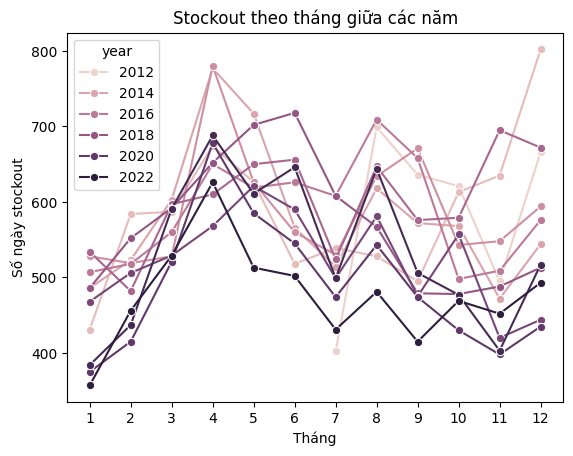

In [36]:
inv = inventory[['snapshot_date', 'stockout_days']].copy()

inv['snapshot_date'] = pd.to_datetime(inv['snapshot_date'])
inv['year'] = inv['snapshot_date'].dt.year
inv['month'] = inv['snapshot_date'].dt.month

monthly = (
    inv.groupby(['year', 'month'])['stockout_days']
    .sum()
    .reset_index()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.lineplot(
    data=monthly,
    x='month',
    y='stockout_days',
    hue='year',
    marker='o'
)

plt.title('Stockout theo tháng giữa các năm')
plt.xlabel('Tháng')
plt.ylabel('Số ngày stockout')

plt.xticks(range(1, 13))
plt.show()

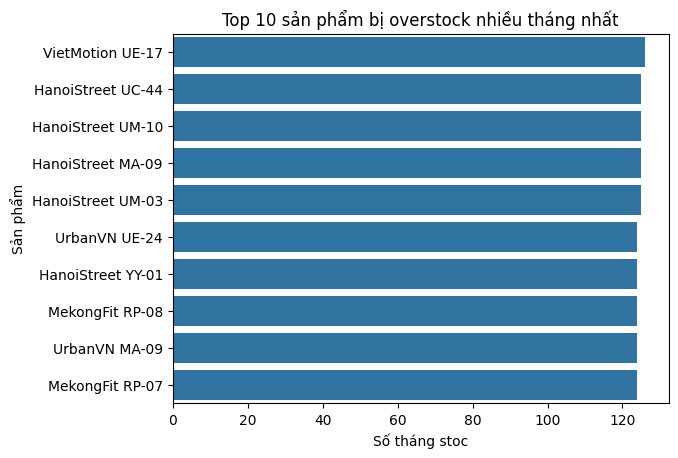

In [37]:
# chỉ lấy cột cần
inv = inventory[['product_id', 'overstock_flag']]
prod_small = products[['product_id', 'product_name']]

# filter sớm để giảm data
stockout = inv[inv['overstock_flag'] == 1]

# group
stockout_per_product = (
    stockout.groupby('product_id')
    .size()
    .reset_index(name='overstock_months')
)

# merge nhẹ (dimension join)
result = stockout_per_product.merge(prod_small, on='product_id', how='left')

# top 10
top_products = result.sort_values('overstock_months', ascending=False).head(10)

# plot
plt.figure()
sns.barplot(data=top_products, x='overstock_months', y='product_name')
plt.title('Top 10 sản phẩm bị overstock nhiều tháng nhất')
plt.xlabel('Số tháng stoc')
plt.ylabel('Sản phẩm')
plt.show()

/tmp/ipykernel_6174/278257608.py:21: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



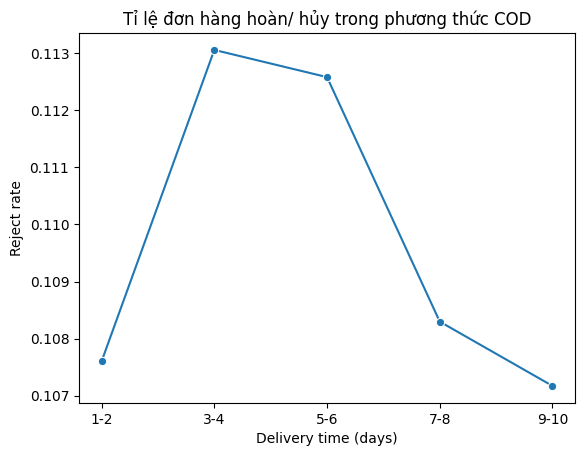

In [38]:
df=payments.merge(shipments,on='order_id',how='left')
df=df.merge(orders,on='order_id',how='left')
cod_df = df[df['payment_method_x'] == 'cod'].copy()
cod_df['delivery_time'] = (
    pd.to_datetime(cod_df['delivery_date']) -
    pd.to_datetime(cod_df['order_date'])
).dt.days

cod_df['is_rejected'] = cod_df['order_status'].isin(['returned', 'cancelled']).astype(int)
bins = [0, 2, 4, 6, 8, 10, 15, 30]
labels = ['1-2', '3-4', '5-6', '7-8', '9-10', '11-15', '15+']

cod_df['delivery_bucket'] = pd.cut(
    cod_df['delivery_time'],
    bins=bins,
    labels=labels,
    right=True
)

agg = (
    cod_df.groupby('delivery_bucket')
    .agg(
        total_orders=('is_rejected', 'count'),
        rejected_orders=('is_rejected', 'sum')
    )
    .reset_index()
)

agg['rejected_rate'] = agg['rejected_orders']/agg['total_orders']

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.lineplot(
    data=agg,
    x='delivery_bucket',
    y='rejected_rate',
    marker='o'
)

plt.title('Tỉ lệ đơn hàng hoàn/ hủy trong phương thức COD')
plt.xlabel('Delivery time (days)')
plt.ylabel('Reject rate')

plt.show()

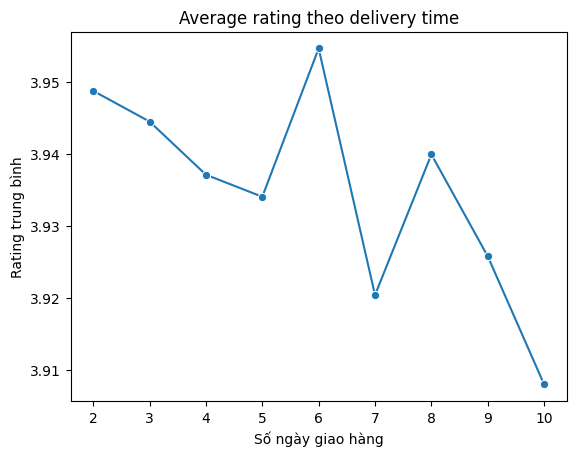

In [39]:
df = df.merge(reviews, on='order_id', how='left', suffixes=('_left', '_right'))
reviews_agg = (
    reviews.groupby('order_id')['rating']
    .mean()
    .reset_index()
    # Removed .rename(columns={'rating': 'avg_order_rating'}) as suffixes will be used
)

df = df.merge(reviews_agg, on='order_id', how='left', suffixes=('_left', '_right'))
df['delivery_time'] = (
    pd.to_datetime(df['delivery_date']) -
    pd.to_datetime(df['order_date'])
).dt.days
agg = (
    df.groupby('delivery_time')
    .agg(
        avg_rating=('rating_right', 'mean'), # Use 'rating_right' from reviews_agg
        total_orders=('order_id', 'nunique') # Count unique orders
    )
    .reset_index()
)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.lineplot(
    data=agg,
    x='delivery_time',
    y='avg_rating',
    marker='o'
)

plt.title('Average rating theo delivery time')
plt.xlabel('Số ngày giao hàng')
plt.ylabel('Rating trung bình')

plt.show()